## Pauli Correlation Encoding to reduce qubits requirements

The goal of this project is to use Pauli Correlation Encoding to encode optimization problems into few qubits.
We will compare classical solvers with quantum solvers, for the Max-Cut problem and for the Maximum Independent Set (MIS).

## What is the Pauli Encoding ?

 *Pauli Correlation Encoding*  is an approach designed to encode optimization problems into qubits with greater efficiency for quantum computation. PCE maps classical variables in optimization problems to multi-body Pauli-matrix correlations, resulting in a polynomial compression of the problem's space requirements. By employing PCE, the number of qubits needed for encoding is reduced, making it particularly advantageous for near-term quantum devices with limited qubit resources. Furthermore, it is analytically demonstrated that PCE inherently mitigates barren plateaus, offering super-polynomial resilience against this phenomenon. This built-in feature enables unprecedented performance in quantum optimization solvers.

## Requirements

Be sure you have the following installed:

* Qiskit SDK v1.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)


## Différents problème : 

## Max-cut : 
Le problème MaxCut est un défi d'optimisation combinatoire NP-difficile qui consiste à partitionner les sommets d'un graphe $G=(V, E)$ en deux sous-ensembles disjoints de telle sorte que la somme des poids des arêtes reliant ces deux ensembles soit maximale. Mathématiquement, on cherche à maximiser la fonction objective $\mathcal{V}(x) = \sum_{(i,j) \in E} W_{ij} (1 - x_i x_j)$, où $W_{ij}$ représente le poids de l'arête entre les sommets $i$ et $j$, et $x_i \in \{-1, 1\}$ indique l'appartenance de chaque sommet à l'une des deux partitions. Ce problème est fondamental car de nombreux défis industriels peuvent y être ramenés, mais son approximation au-delà d'un ratio de 0,941 est considérée comme calculatoirement impossible pour des algorithmes classiques en temps polynomial. L'approche par Encodage par Corrélations de Pauli (PCE) permet de s'attaquer à ce problème à grande échelle en compressant les $m$ variables de décision dans un nombre réduit de qubits $n$, offrant ainsi une voie prometteuse pour les dispositifs quantiques actuels.

## Maximal Independant Set :
## Maximum Independent Set (MIS) :
Le problème du Maximum Independent Set (MIS) consiste à trouver le plus grand sous-ensemble de sommets d'un graphe tel qu'aucun de ces sommets ne soit adjacent à un autre (aucune arête ne doit relier deux sommets du set). C'est un problème NP-difficile au cœur de nombreuses applications réelles, comme l'allocation de fréquences en télécommunications (deux antennes proches ne peuvent pas émettre sur la même fréquence sans interférence) ou la compression de données. 
Contrairement à des problèmes de routage, son évaluation est purement locale : la fonction de coût cherche à maximiser le nombre de nœuds choisis tout en appliquant une forte pénalité si deux nœuds connectés sont sélectionnés simultanément. Cette structure QUBO (Quadratic Unconstrained Binary Optimization) est particulièrement naturelle et bien adaptée à l'encodage PCE, permettant de compresser les variables dans un minimum de qubits tout en évitant des calculs classiques intermédiaires complexes.

## Choix du problème à résoudre :

Choisissez parmi "Max-Cut" et "MIS" le problème que vous souhaitez résoudre.

In [1]:
# problem = "Max-Cut"
problem = "MIS"

## Création de l'instance de résolution du problème
- soit on importe un graphe/arbre de son choix
- soit on utilise le générateur d'instance pour créer un graphe/arbre

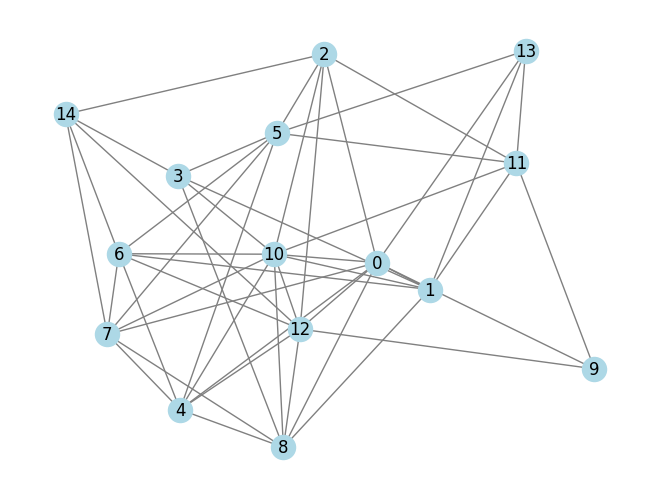

In [2]:
from instance_generator import graph_creation
import matplotlib.pyplot as plt
import networkx as nx
num_nodes = 15

instance = graph_creation(num_nodes)
nx.draw(instance, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

## Résolution classique : 

In [3]:
from classical_solvers import classical_solver

classical_cut_size, classical_partition = classical_solver(instance, problem)

Independent set: {2, 3, 4, 9, 13}


## Encodage de Pauli des noeuds du graphe : 

In [4]:
from variables_encoding import variables_encoding

num_qubits = 4

pce_groups = variables_encoding(num_nodes, num_qubits)

List X: [0, 3, 6, 9, 12]
List Y: [1, 4, 7, 10, 13]
List Z: [2, 5, 8, 11, 14]
[SparsePauliOp(['IIXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIXI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIYY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIYI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIZI'],
              coeffs=[1.+0.j])]


## Résolution quantique :

In [ ]:
from quantum_solvers import solve_maxcut_pce, solve_mis_pce
from utils import calc_cut_size

if problem == "Max-Cut":
    results = solve_maxcut_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, max_iter=150)

    # Affichage des résultats 
    print(f"Partition 0 : {results['par0']}")
    print(f"Partition 1 : {results['par1']}")

    # Calcul de la taille du cut final
    cut_size = calc_cut_size(instance, results['par0'], results['par1'])
    print(f"Taille du Cut : {cut_size}")

elif problem == "MIS":
    results = solve_mis_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, reps=4, max_iter=300)

    # Affichage des résultats 
    print(f"Independent set : {results['independent_set']}")

    # Calcul de la taille de l'ensemble indépendant final
    independent_set_size = len(results['independent_set'])
    print(f"Taille de l'ensemble indépendant : {independent_set_size}")

Iter 0: 4.041222079931775
Iter 1: 5.3497594977771055
Iter 2: 5.968750181899385
Iter 3: 4.013501785469479
Iter 4: 3.627275017091561
Iter 5: 6.313636541034453
Iter 6: 6.542123747583882
Iter 7: 4.140045273402727
Iter 8: 2.216781202229743
Iter 9: 2.159308867157766
Iter 10: 2.038887766248777
Iter 11: 2.1269435004056017
Iter 12: 1.6028850172272613
Iter 13: 2.8140820153228105
Iter 14: 2.263148909853819
Iter 15: 3.935108380231517
Iter 16: 2.343571779581613
Iter 17: 2.1009084083682783
Iter 18: 5.54212559033954
Iter 19: 4.598626342325557
Iter 20: 3.596740982600129
Iter 21: 2.9044343832045714
Iter 22: 2.3401454052771395
Iter 23: 4.103128882114784
Iter 24: 3.963506526718608
Iter 25: 3.1108480673687895
Iter 26: 5.755587597448878
Iter 27: 3.2951139383054957
Iter 28: 2.4544689954813057
Iter 29: 3.965600832734186
Iter 30: 2.398769808884265
Iter 31: 1.4116132293863473
Iter 32: 3.1139451424168545
Iter 33: 2.5808464666695605
Iter 34: 4.844789251589216
Iter 35: 1.887605248231675
Iter 36: 3.295504619755282

C:\Users\marti\AppData\Local\Temp\ipykernel_21732\675529899.py:16: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  results = solve_mis_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, reps=3, max_iter=300)
C:\Users\marti\AppData\Local\Temp\ipykernel_21732\675529899.py:16: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  results = solve_mis_pce(num_qubits=4, pce_groups=pce_groups, instance=instance, reps=3, max_iter=300)


Independent set : {9, 5}
Taille de l'ensemble indépendant : 2


## Post Processing par bit-swap :

In [6]:
# from utils import bit_swap

# best_cut, best_bits = bit_swap(results, instance)
# print(f"Best cut size after bit swap: {best_cut}")
# print(f"Best bit configuration: {best_bits}")

## Métriques et évaluation

Setup

In [7]:
# Configuration
sizes = [6, 8, 10, 12]  # Tailles de graphes à tester (m)
problem = "Max-Cut"
all_reports = []
history_to_plot = None # Pour garder l'historique du dernier run

Calcul

In [8]:
from classical_solvers import classical_solver
from instance_generator import graph_creation
from variables_encoding import variables_encoding
from metrics import compare_solvers
from quantum_solvers import solve_maxcut_pce
import numpy as np

classical_values = []
quantum_values = []
approx_ratios = []

for m in sizes:
    print(f"--- Évaluation pour m = {m} sommets ---")
    
    # 1. Génération de l'instance
    graph_bis = graph_creation(m) # On récupère la version NetworkX
    
    # 2. Résolution Classique (Baseline)
    c_value, _ = classical_solver(graph_bis, problem)
    classical_values.append(c_value)
    
    # 3. Préparation PCE (Calcul du nombre de qubits n = ceil(sqrt(m)))
    n_qubits_bis = int(np.ceil(np.sqrt(m)))
    print(f"Nombre de qubits nécessaires pour m={m} : {n_qubits_bis}")
    # Correction : dictionnaire indexé par les nœuds
    pce_groups_bis = variables_encoding(m, n_qubits_bis)

    # Le reste est inchangé
    q_result = solve_maxcut_pce(num_qubits=n_qubits_bis, pce_groups=pce_groups_bis, instance=graph_bis, max_iter=50 + m)
    
    # --- Correction debug ---
    missing = [i for i in graph_bis.nodes() if i not in pce_groups_bis]
    if missing:
        raise ValueError(f"Aucun opérateur PCE généré pour les nœuds {missing} (incohérence entre le graphe et l'encodage)")
    
    
    report = compare_solvers(graph_bis, c_value, q_result, problem)
    
    quantum_values.append(report['quantum_objective'])
    approx_ratios.append(report['approximation_ratio'])
    all_reports.append(report)
    
    # On sauvegarde l'historique du dernier pour la viz de convergence
    history_to_plot = q_result['history']['loss']

print("\nExpériences terminées.")

--- Évaluation pour m = 6 sommets ---
Cut size: 6
Partition 1: {0, 5}
Partition 2: {1, 2, 3, 4}
Nombre de qubits nécessaires pour m=6 : 3
List X: [0, 3]
List Y: [1, 4]
List Z: [2, 5]
[SparsePauliOp(['IXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIX'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IYY'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIY'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIZ'],
              coeffs=[1.+0.j])]
Iter 0: 0.9139508173522728
Iter 1: 0.44316273009545154
Iter 2: 0.01616965325485903
Iter 3: -0.6504136298267551
Iter 4: -0.8079909334660629
Iter 5: -0.6722985768300475
Iter 6: -2.0112539268170178
Iter 7: -2.1426513410098567
Iter 8: -2.0031279107268203
Iter 9: -1.9338962548280156
Iter 10: -0.5520647267752486
Iter 11: -1.69001341208276
Iter 12: -1.9411372198003622
Iter 13: -1.1385914635501042
Iter 14: -1.5774388696764516
Iter 15: -1.6633869022409289
Iter 16: -1.093101236408641
Iter 

C:\Users\marti\AppData\Local\Temp\ipykernel_21732\1418223156.py:29: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  q_result = solve_maxcut_pce(num_qubits=n_qubits_bis, pce_groups=pce_groups_bis, instance=graph_bis, max_iter=50 + m)
C:\Users\marti\AppData\Local\Temp\ipykernel_21732\1418223156.py:29: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  q_result = solve_maxcut_pce(num_qubits=n_qubits_bis, pce_groups=pce_groups_bis, instance=graph_bis, max_iter=50 + m)


ValueError: Aucun opérateur PCE généré pour les nœuds [0, 1, 2, 3, 4, 5] (incohérence entre le graphe et l'encodage)

Affichage

In [ ]:
# Graphique 1 : Comparaison des valeurs de Cut (Scaling)
plot_performance_scaling(sizes, classical_values, quantum_values, problem_type=problem)

# Graphique 2 : Évolution du ratio d'approximation
# (On veut voir si on reste proche de 1.0 même quand m augmente)
plot_approximation_ratio_scaling(sizes, approx_ratios, problem_type=problem)

# Graphique 3 : Convergence de l'optimiseur (pour le dernier run)
plot_objective_evolution(history_to_plot, title=f"Convergence pour m={sizes[-1]}")